<a href="https://colab.research.google.com/github/sima-mohmdy/computational-data-mining/blob/main/MNIST_QR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import patoolib
from skimage.io import imread_collection
from sklearn.metrics import accuracy_score

# Read train data

In [ ]:
pip install patool

In [ ]:
#pip install patool
import patoolib
patoolib.extract_archive("/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST.rar", outdir="path here")

count files in a folder

In [3]:
import os

file_count = sum(len(files) for _, _, files in os.walk('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST'))
print(file_count)

4600


In [4]:
import os

file_count = sum(len(files) for _, _, files in os.walk('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train'))
print(file_count)

3998


In [19]:
import os

file_count = sum(len(files) for _, _, files in os.walk('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/test'))
print(file_count)

600


In [6]:
#creating a collection with the available images
train0 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/0/*.jpg')
train1 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/1/*.jpg')
train2 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/2/*.jpg')
train3 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/3/*.jpg')
train4 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/4/*.jpg')
train5 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/5/*.jpg')
train6 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/6/*.jpg')
train7 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/7/*.jpg')
train8 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/8/*.jpg')
train9 = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/train/9/*.jpg')

In [ ]:
#print('shape of class 0 =', np.shape(train0))
#print('shape of class 1 =', np.shape(train1))
#print('shape of class 2 =', np.shape(train2))
#print('shape of class 3 =', np.shape(train3))
#print('shape of class 4 =', np.shape(train4))
#print('shape of class 5 =', np.shape(train5))
#print('shape of class 6 =', np.shape(train6))
#print('shape of class 7 =', np.shape(train7))
#print('shape of class 8 =', np.shape(train8))
#print('shape of class 9 =', np.shape(train9))

# Show some images as example

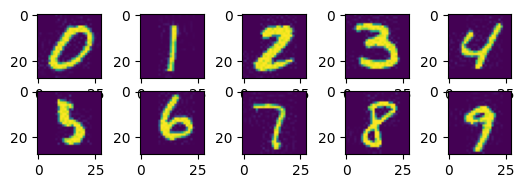

In [7]:
import matplotlib.pyplot as plt

train = [train0, train1, train2, train3, train4, train5, train6, train7, train8, train9]

fig=plt.figure()
for i in range(len(train)):
    plt.subplot(5,5,i+1)
    #plt.imshow(train[i][i])
    plt.imshow(train[i][1])
plt.show()

# calculate A0 to A9 for every classes

In [8]:
def creat_matrix(train_class):

  a = np.zeros((0, 784))

  for image in train_class:
    flatten_image = image.flatten()
    a = np.vstack((a,flatten_image))

  A = a.T
  return A


train = [train0, train1, train2, train3, train4, train5, train6, train7, train8, train9]

A_matrices = []
for train_class in train:
  A = creat_matrix(train_class)
  A_matrices.append(A)
  print(A.shape)

(784, 400)
(784, 400)
(784, 400)
(784, 400)
(784, 402)
(784, 400)
(784, 400)
(784, 400)
(784, 400)
(784, 396)


# Vectorize test datas


In [9]:
#creating a collection with the available images
test = imread_collection('/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/test/test/*.jpg')
print('shape of test =', np.shape(test))

shape of test = (600, 28, 28)


In [11]:
flattend_test = []
for img_test in test:
  flatten_image = img_test.flatten()
  flattend_test.append(flatten_image)
print('len of flattend test: ', len(flattend_test))

len of flattend test:  600


In [12]:
# test_data_labels
test_labels = pd.read_csv("/content/drive/MyDrive/ML/computational data mining/تمرین دوم/TinyMNIST/test labels.csv")
test_labels

,id,category
0,0,1
1,1,0
2,2,1
3,3,4
4,4,0
...,...,...
595,653,8
596,654,7
597,659,6
598,672,8


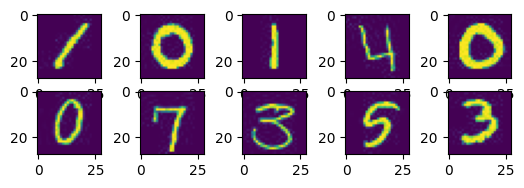

In [13]:
import matplotlib.pyplot as plt

fig=plt.figure()
for i in range(10):
    plt.subplot(5,5,i+1)

    plt.imshow(test[i])
plt.show()

# solve least square error with qr decomposition

decompose Q, R

In [14]:
# decompose Q, R from A(matrices that come from previous function)
def QR_decomposition(A):
  Q, R = np.linalg.qr(A)
  return Q, R


Q_matrices = []
R_matrices = []

for A in A_matrices:
  Q, R = QR_decomposition(A)
  Q_matrices.append(Q)
  R_matrices.append(R)

  print('Q shape: ', Q.shape)
  print('R shape: ', R.shape)

Q shape:  (784, 400)
R shape:  (400, 400)
Q shape:  (784, 400)
R shape:  (400, 400)
Q shape:  (784, 400)
R shape:  (400, 400)
Q shape:  (784, 400)
R shape:  (400, 400)
Q shape:  (784, 402)
R shape:  (402, 402)
Q shape:  (784, 400)
R shape:  (400, 400)
Q shape:  (784, 400)
R shape:  (400, 400)
Q shape:  (784, 400)
R shape:  (400, 400)
Q shape:  (784, 400)
R shape:  (400, 400)
Q shape:  (784, 396)
R shape:  (396, 396)


Solving Ordinary Least Squares

In [16]:
# Solving Ordinary Least Squares Using QR Decomposition
def solve_x(Q, x):

  # Compute Q^T * x
  c = np.dot(Q.T, x)
  # Compute x_hat = Qi ci
  x_hat = np.dot(Q, c)
  return x_hat

x_hat = []
for x in flattend_test:
  x_hats = []
  for Q in Q_matrices:
    x_hats.append(solve_x(Q, x))
  x_hat.append(x_hats)

#print('X hat: ', x_hat)
print('len of X hat: ', len(x_hat))

len of X hat:  600


# Predict label for test datas

In [21]:
# Calculate reconstruction error and predicted class

#error = ||x - x_hat||
#prediction = argmin(error)

predictions = []

for i in range(len(flattend_test)):

    x_true = flattend_test[i]
    error_list = []

    for x_bar in x_hat[i]:

        error = np.linalg.norm(x_true - x_bar)
        error_list.append(error)

    prediction = np.argmin(error_list)
    predictions.append(prediction)

#print(predictions)
print("Number of predictions:", len(predictions))
print("First 20 predictions:", predictions[:10])

Number of predictions: 600
First 20 predictions: [np.int64(1), np.int64(0), np.int64(1), np.int64(4), np.int64(0), np.int64(0), np.int64(7), np.int64(3), np.int64(8), np.int64(3)]


# Calculate Accuracy

In [22]:
# Using accuracy_score function
accuracy = accuracy_score(test_labels['category'], predictions)
print(f'Accuracy: {accuracy:.2%}')

Accuracy: 82.33%
